**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
M.C. Joan Manuel Raygoza Romero

# ICD - 8: Reducción de dimensionalidad

Sesión 8 del curso. Diapositivas: [icd-08-reduccion.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/icd-08-reduccion.pdf)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/husseinlopez/icd2026/blob/main/icd-08-reduccion.ipynb)

1. Preparación y conjunto de datos.
2. PCA: proyección y varianza explicada.
3. Kernel PCA con kernel RBF.
4. t-SNE.
5. UMAP.
6. Resumen de los métodos.
7. Comparación visual y reconstrucción de datos no vistos.

Ejecuta las celdas en orden. Los datos vienen incluidos en scikit-learn; no se descargan archivos externos. La instalación de bibliotecas sí requiere internet.

## 1. Preparación y datos
### 1.1 Bibliotecas
Si falta alguna biblioteca, descomenta la siguiente celda y ejecútala. En Colab normalmente solo es necesario instalar `umap-learn`. El paquete se instala como **umap-learn**, pero se importa como **umap**. Se usa scikit-learn ≥ 1.5 por el argumento `max_iter` de t-SNE.

In [ ]:
# %pip install numpy pandas matplotlib scipy "scikit-learn>=1.5" umap-learn

In [1]:
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from IPython.display import display
from scipy.spatial.distance import pdist
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import umap

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 10, 'figure.dpi': 110})
for paquete in ['numpy', 'pandas', 'scikit-learn', 'umap-learn']:
    print(f'{paquete}: {version(paquete)}')

numpy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1
umap-learn: 0.5.12


### 1.2 Un mismo conjunto de datos: dígitos manuscritos

Usamos `load_digits`, distribuido con scikit-learn y procedente del conjunto de reconocimiento de dígitos de UCI. Contiene **1797 imágenes de 8 × 8 píxeles**, correspondientes a los dígitos 0 a 9. No es MNIST.

| Elemento | Descripción | Forma / valores |
|---|---|---|
| Observación | Una imagen de un dígito manuscrito | 8 × 8 píxeles |
| `X_original` | Imagen aplanada por filas; 64 intensidades | (1797, 64), valores de 0 a 16 |
| `X` | Intensidades divididas entre 16 | (1797, 64), valores de 0 a 1 |
| `y` | Dígito representado | (1797,), clases 0, …, 9 |
| `Z` | Representación reducida de cada imagen | (n, 2) |

La columna `pixel_r_c` indica la intensidad en la fila `r` y la columna `c`, con índices de 0 a 7. **Las etiquetas no se entregan a los reductores:** solo se usan para estratificar la división, colorear las figuras.

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0


Datos: (1797, 64) | Clases: [0 1 2 3 4 5 6 7 8 9]
Faltantes: 0 | Rango: (np.float32(0.0), np.float32(1.0))


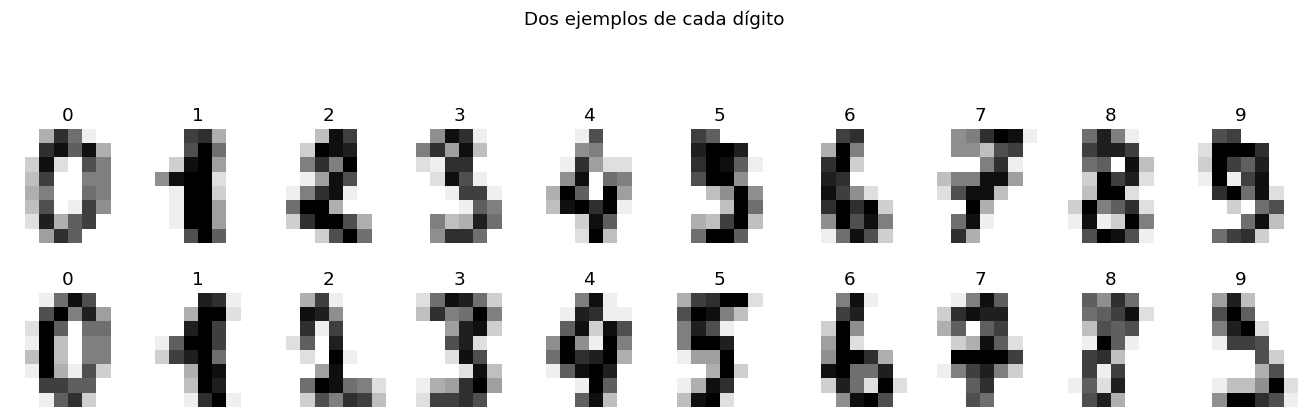

In [2]:
digitos = load_digits()
X_original = digitos.data.astype(np.float32)
y = digitos.target
X = X_original / 16.0

columnas = [f'pixel_{r}_{c}' for r in range(8) for c in range(8)]
tabla = pd.DataFrame(X_original, columns=columnas)
display(tabla.iloc[:5, :10])
print('Datos:', X.shape, '| Clases:', np.unique(y))
print('Faltantes:', np.isnan(X).sum(), '| Rango:', (X.min(), X.max()))

fig, axes = plt.subplots(2, 10, figsize=(12, 4.2))
for d in range(10):
    indices = np.flatnonzero(y == d)[:2]
    for fila, indice in enumerate(indices):
        axes[fila, d].imshow(X[indice].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        axes[fila, d].set_title(str(d))
        axes[fila, d].axis('off')
fig.suptitle('Dos ejemplos de cada dígito')
plt.tight_layout(rect=(0, 0, 1, 0.92), h_pad=1.5); plt.show()

### 1.3 Protocolo común y escalado

Dividimos una sola vez: **80% entrenamiento y 20% prueba**.

- Los cuatro métodos se ajustan con las mismas imágenes de `X_train` y generan dos coordenadas por imagen.
- La comparación visual usa entrenamiento: t-SNE de scikit-learn no dispone de `transform` para proyectar imágenes nuevas al mapa aprendido.
- `X_test` se reserva para mostrar la reconstrucción con PCA de imágenes no vistas. No se utiliza para ajustar el modelo ni para elegir el número de componentes.

Todos los métodos reciben la misma transformación fija:

$$x'_{ij}=x_{ij}/16.$$

Los píxeles comparten unidad y rango conocido. Dividir entre 16 no estima parámetros a partir de prueba. No usamos `StandardScaler`, que daría más peso relativo a píxeles de baja varianza. PCA realiza además su propio centrado con la media de entrenamiento.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
display(pd.DataFrame({
    'Partición': ['Entrenamiento', 'Prueba'],
    'Imágenes': [len(X_train), len(X_test)],
    'Variables de entrada': [64, 64]
}))
representaciones = {}

,Partición,Imágenes,Variables de entrada
0,Entrenamiento,1437,64
1,Prueba,360,64


### 1.4 Función para la comparación visual de la sección 7
El dígito tiene el mismo color en todas las figuras. Cada método tiene ejes y escalas propios: la orientación y el tamaño de los mapas no se comparan directamente. En t-SNE y UMAP, la distancia entre grupos separados no debe interpretarse como una distancia fiel entre clases originales.

In [4]:
cmap = plt.get_cmap('tab10')
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

def dibujar_mapa(Z, etiquetas, titulo, ax=None):
    """Dibuja dos coordenadas por imagen con colores discretos por dígito."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4.5))
    puntos = ax.scatter(Z[:, 0], Z[:, 1], c=etiquetas, cmap=cmap, norm=norm,
                        s=13, alpha=0.8, linewidths=0)
    ax.set(title=titulo, xlabel='Dimensión 1', ylabel='Dimensión 2')
    return puntos

## 2. PCA: una referencia lineal
### 2.1 Ajustar y proyectar

PCA centra los datos y encuentra direcciones ortogonales de máxima varianza. Para conservar dos componentes:

$$X_c=X-\mu,\qquad C=\frac{X_c^T X_c}{n-1},\qquad C v_j=\lambda_jv_j,\qquad Z=X_cV_2.$$

`fit_transform` aprende la media y las direcciones, y calcula las coordenadas. Las componentes son **no correlacionadas** en entrenamiento; esto no implica independencia estadística. La varianza conservada tampoco equivale a un porcentaje de información útil para cualquier tarea.

Forma: (1437, 2)
Varianza por componente: [0.1476 0.1374]
Varianza acumulada en 2D: 28.5%


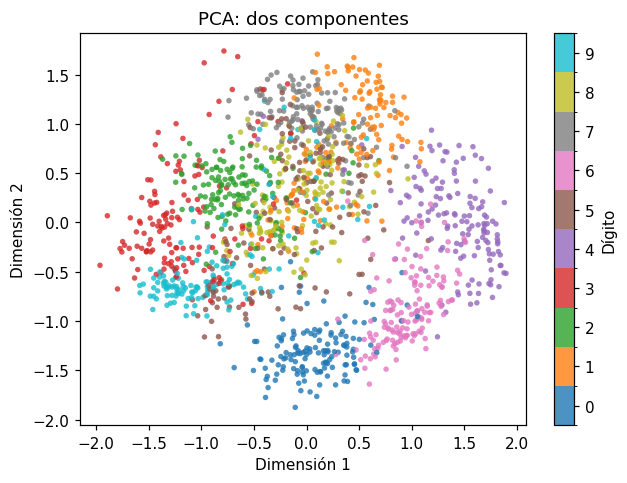

In [16]:
pca = PCA(n_components=2, svd_solver='full')
Z_pca = pca.fit_transform(X_train)
representaciones['PCA'] = Z_pca

print('Forma:', Z_pca.shape)
print('Varianza por componente:', pca.explained_variance_ratio_.round(4))
print(f'Varianza acumulada en 2D: {pca.explained_variance_ratio_.sum():.1%}')
puntos = dibujar_mapa(Z_pca, y_train, 'PCA: dos componentes')
plt.colorbar(puntos, ticks=range(10), label='Dígito')
plt.tight_layout(); plt.show()

### 2.2 Los cuatro pasos con NumPy
Reproducimos el procedimiento de las diapositivas. `np.linalg.eigh` se utiliza porque la covarianza es simétrica. El signo de un eigenvector es arbitrario: dos implementaciones pueden producir mapas reflejados y representar la misma solución. Por eso comparamos eigenvalores y el subespacio, no exigimos coordenadas idénticas.

In [6]:
media = X_train.mean(axis=0, dtype=np.float64)
X_c = X_train.astype(np.float64) - media                  # 1. Centrar
C = X_c.T @ X_c / (len(X_c) - 1)                       # 2. Covarianza
eigenvalores, eigenvectores = np.linalg.eigh(C)          # 3. Descomponer
orden = np.argsort(eigenvalores)[::-1]
eigenvalores = eigenvalores[orden]
V = eigenvectores[:, orden]
Z_manual = X_c @ V[:, :2]                              # 4. Proyectar

print('Eigenvalores NumPy:', eigenvalores[:2].round(5))
print('Eigenvalores sklearn:', pca.explained_variance_.round(5))
print('Mismo subespacio:', np.allclose(
    V[:, :2] @ V[:, :2].T, pca.components_.T @ pca.components_, atol=1e-5
))

Eigenvalores NumPy: [0.69144 0.64382]
Eigenvalores sklearn: [0.69144 0.64382]
Mismo subespacio: True


### 2.3 ¿Cuántas componentes conservan el 95% de la varianza?

$$R_k=\sum_{j=1}^k r_j,\qquad r_j=\frac{\lambda_j}{\sum_\ell\lambda_\ell}.$$

Este cálculo permite preparar una segunda reconstrucción con PCA en la sección 7. **La comparación entre los cuatro métodos sigue usando dos dimensiones**, aunque PCA necesite más para alcanzar 95%.

Se necesitan 28 componentes para conservar al menos 95% de la varianza de entrenamiento.


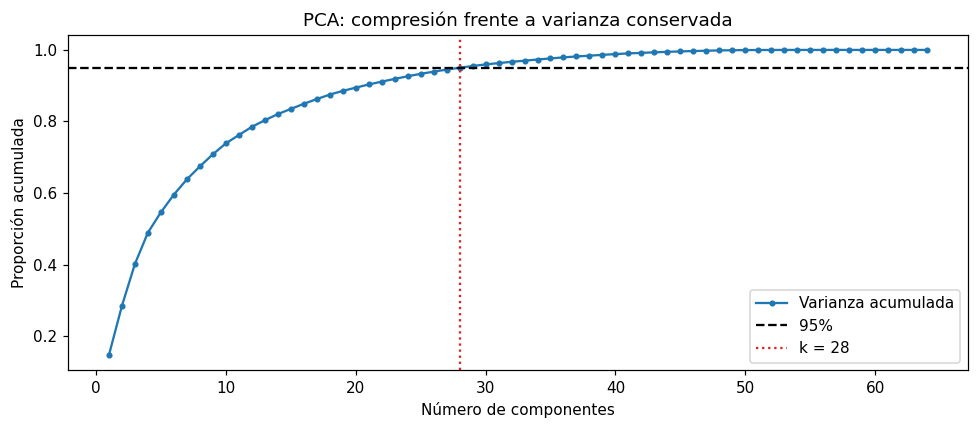

Se necesitan 28 componentes para conservar al menos 95% de la varianza.


In [17]:
pca_completo = PCA(svd_solver='full').fit(X_train)
acumulada = np.cumsum(pca_completo.explained_variance_ratio_)
k95 = np.searchsorted(acumulada, 0.95) + 1
print(f'Se necesitan {k95} componentes para conservar al menos 95% de la varianza de entrenamiento.')

plt.plot(np.arange(1, 65), acumulada, marker='.', label='Varianza acumulada')
plt.axhline(0.95, color='black', linestyle='--', label='95%')
plt.axvline(k95, color='tab:red', linestyle=':', label=f'k = {k95}')
plt.xlabel('Número de componentes'); plt.ylabel('Proporción acumulada')
plt.title('PCA: compresión frente a varianza conservada')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Se necesitan {k95} componentes para conservar al menos 95% de la varianza.')

## 3. Kernel PCA (KPCA)

Usamos un kernel RBF para comparar imágenes:

$$K(x_i,x_j)=\exp\left(-\gamma\lVert x_i-x_j\rVert^2\right).$$

KPCA realiza PCA en el espacio implícito del kernel. `gamma` controla qué tan rápido disminuye la similitud con la distancia. Como punto de partida reproducible usamos el inverso de la mediana de las distancias cuadradas de entrenamiento; **es una heurística, no un valor óptimo**.

No interpretamos sus eigenvalores como proporciones de varianza explicada en los píxeles originales. La matriz de kernel requiere memoria que crece aproximadamente como $n^2$.

Gamma: 0.1065 | Forma: (1437, 2)


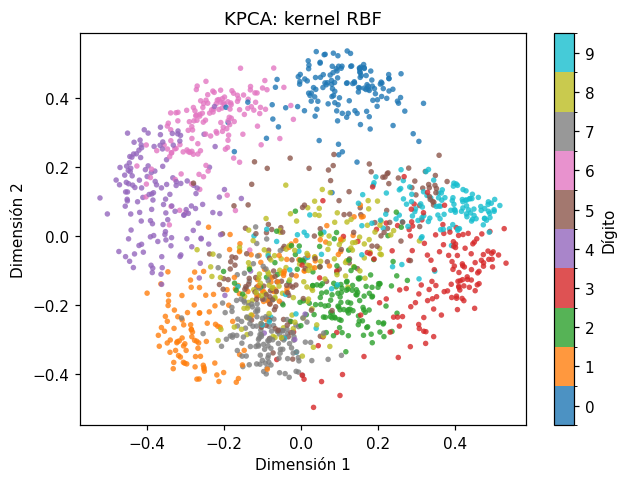

In [18]:
distancias_cuadradas = pdist(X_train, metric='sqeuclidean')
gamma = 1.0 / np.median(distancias_cuadradas[distancias_cuadradas > 0])
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma,
                 eigen_solver='arpack', random_state=SEED)
Z_kpca = kpca.fit_transform(X_train)
representaciones['KPCA'] = Z_kpca

print(f'Gamma: {gamma:.4f} | Forma: {Z_kpca.shape}')
puntos = dibujar_mapa(Z_kpca, y_train, 'KPCA: kernel RBF')
plt.colorbar(puntos, ticks=range(10), label='Dígito')
plt.tight_layout(); plt.show()

## 4. t-SNE

t-SNE construye similitudes entre observaciones y busca un mapa que conserve principalmente vecindades locales. Minimiza una divergencia entre probabilidades:

$$\mathrm{KL}(P\Vert Q)=\sum_{i\ne j}p_{ij}\log\frac{p_{ij}}{q_{ij}}.$$

- `perplexity=30`: controla la escala efectiva de vecindad; no es un número exacto de vecinos y debe ser menor que el número de muestras.
- `init='pca'`: inicializa el mapa usando PCA; el algoritmo recibe los mismos 64 píxeles que los otros métodos.
- `max_iter=1000`: máximo de iteraciones de optimización.

La divergencia KL es el objetivo interno de t-SNE. Aquí evaluaremos el mapa solo de manera visual en la sección 7. Esta implementación no permite proyectar datos nuevos con `transform`.

Forma: (1437, 2)
KL final: 0.6891


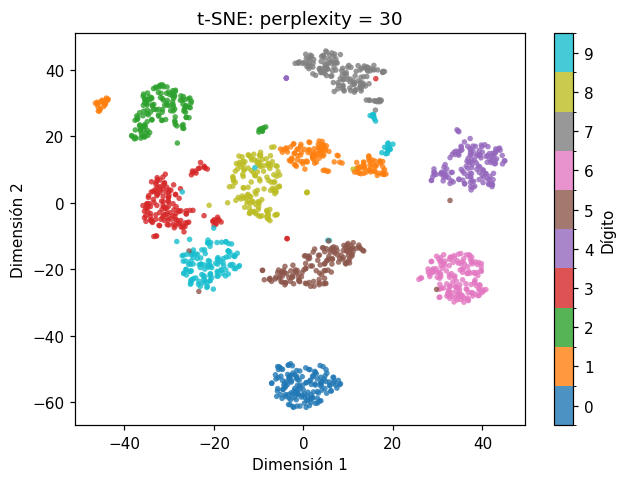

In [19]:
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto',
            max_iter=1000, random_state=SEED, n_jobs=1)
Z_tsne = tsne.fit_transform(X_train)
representaciones['t-SNE'] = Z_tsne
print("Forma:", Z_tsne.shape)

print(f'KL final: {tsne.kl_divergence_:.4f}')
puntos = dibujar_mapa(Z_tsne, y_train, 't-SNE: perplexity = 30')
plt.colorbar(puntos, ticks=range(10), label='Dígito')
plt.tight_layout(); plt.show()

## 5. UMAP

UMAP construye un grafo de vecinos y optimiza su representación en baja dimensión.

- `n_neighbors=15`: controla la escala de vecindad usada para construir el grafo.
- `min_dist=0.1`: controla qué tan compactos pueden quedar los puntos en el mapa.
- `metric='euclidean'`: calcula distancias euclidianas entre las imágenes escaladas.

Fijamos la semilla y un solo trabajador. UMAP permite transformar observaciones nuevas, pero tampoco garantiza conservar fielmente todas las distancias globales. Su primera ejecución puede incluir compilación de Numba; por eso puede tardar más que las siguientes.

Forma: (1437, 2)


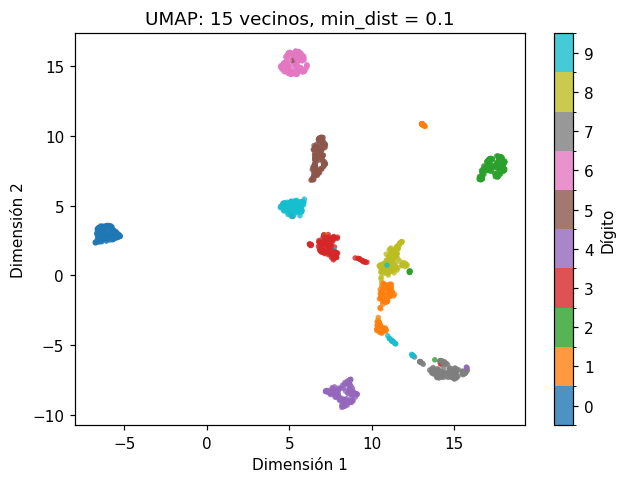

In [20]:
reductor_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                          metric='euclidean', random_state=SEED, n_jobs=1)
Z_umap = reductor_umap.fit_transform(X_train)
representaciones['UMAP'] = Z_umap
print("Forma:", Z_umap.shape)

puntos = dibujar_mapa(Z_umap, y_train, 'UMAP: 15 vecinos, min_dist = 0.1')
plt.colorbar(puntos, ticks=range(10), label='Dígito')
plt.tight_layout(); plt.show()

## 6. Resumen de los métodos

| Método | Tipo | Parámetros principales | Proyectar datos nuevos | Reconstrucción en esta práctica |
|---|---|---|---|---|
| PCA | Lineal | Número de componentes | Sí, `transform` | Sí, `inverse_transform` |
| KPCA | No lineal, RBF | Kernel, gamma, componentes | Sí, `transform` | No calculada |
| t-SNE | No lineal | Perplexity, iteraciones | No mediante `transform` | No disponible |
| UMAP | No lineal | Vecinos, min_dist, componentes | Sí, `transform` | No calculada |

Las cuatro representaciones contienen dos coordenadas por imagen. PCA dispone de una reconstrucción lineal directa. KPCA y UMAP pueden ofrecer aproximaciones inversas con otras configuraciones, pero en esta práctica la reconstrucción se realiza únicamente con PCA.

## 7. Comparación visual y reconstrucción de datos no vistos
### 7.1 Los cuatro mapas sobre las mismas imágenes

Cada panel contiene las mismas imágenes de entrenamiento y usa los mismos colores por dígito. Observa qué clases se superponen, cuáles forman grupos y cómo cambia la vecindad aparente.

Los ejes tienen escalas propias: no compares directamente rotaciones, tamaños ni distancias entre paneles. En especial, t-SNE y UMAP pueden exagerar la separación entre grupos. Una separación visual más clara no garantiza conservar más información ni generalizar mejor.

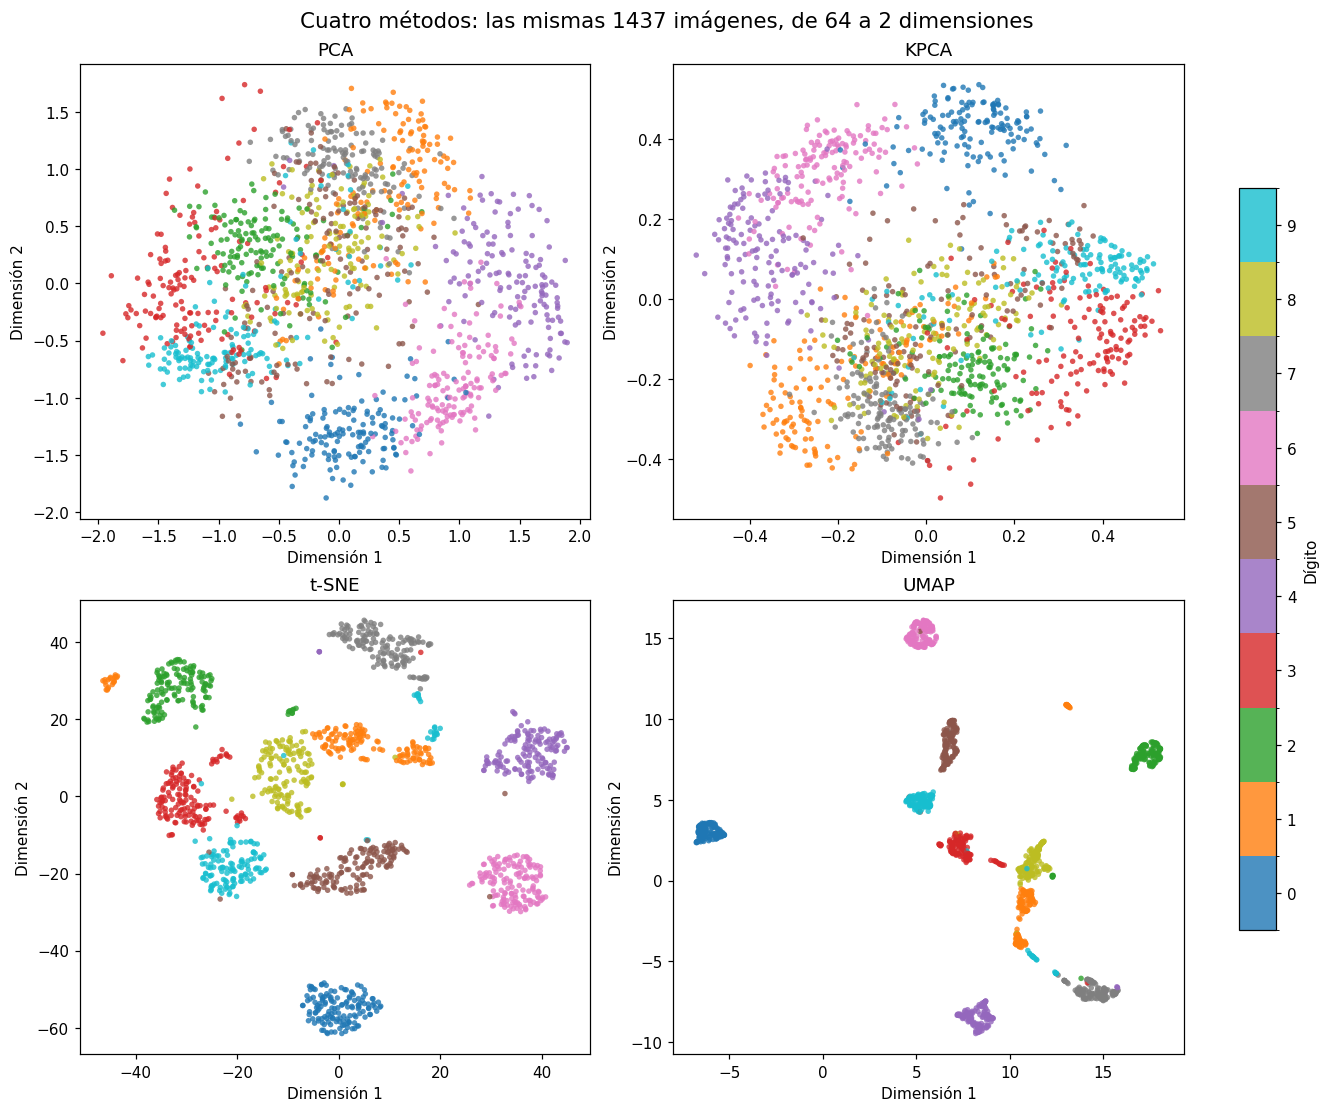

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), layout='constrained')
for ax, (nombre, Z) in zip(axes.flat, representaciones.items()):
    puntos = dibujar_mapa(Z, y_train, nombre, ax)
fig.colorbar(puntos, ax=axes.ravel().tolist(), ticks=range(10), label='Dígito', shrink=0.75)
fig.suptitle(f'Cuatro métodos: las mismas {len(X_train)} imágenes, de 64 a 2 dimensiones', fontsize=14)
plt.show()

### 7.2 Reconstrucción con PCA de imágenes no vistas

Usamos los modelos ajustados únicamente con entrenamiento. Para una imagen de prueba:

$$Z_{\mathrm{test}}=(X_{\mathrm{test}}-\mu_{\mathrm{train}})V_k,$$

$$\hat{X}_{\mathrm{test}}=Z_{\mathrm{test}}V_k^T+\mu_{\mathrm{train}}.$$

Comparamos visualmente la imagen original con dos reconstrucciones:

- **PCA con 2 componentes:** permite ver cuánto detalle se pierde con la representación usada en los mapas.
- **PCA con 95% de varianza de entrenamiento:** utiliza el `k95` calculado en la sección 2. Dispone de más componentes; ilustra el efecto de conservar más dimensiones.

No volvemos a ajustar ningún modelo con prueba. Seleccionamos el primer ejemplo de cada dígito en prueba, sin buscar los que mejor se reconstruyen. Todas las imágenes usan la misma escala de grises [0, 1]; valores reconstruidos fuera de ese rango se limitan solo en la visualización.

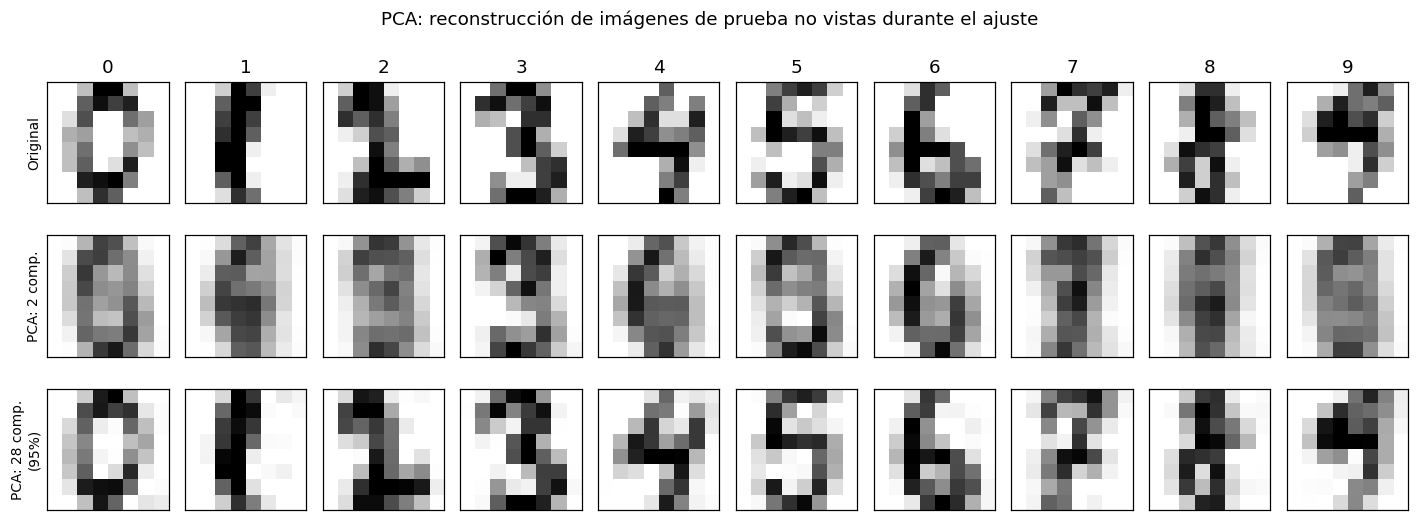

In [22]:
# Reconstrucción desde el modelo de dos componentes, ajustado con X_train.
Z_test_pca = pca.transform(X_test)
recon_pca2 = pca.inverse_transform(Z_test_pca)

# El modelo completo y k95 también se obtuvieron exclusivamente con X_train.
Z_test_completo = pca_completo.transform(X_test)
Z_test_95 = np.zeros_like(Z_test_completo)
Z_test_95[:, :k95] = Z_test_completo[:, :k95]
recon_pca95 = pca_completo.inverse_transform(Z_test_95)

indices = [np.flatnonzero(y_test == d)[0] for d in range(10)]
filas = [
    ('Original', X_test),
    ('PCA: 2 comp.', recon_pca2),
    (f'PCA: {k95} comp.\n(95%)', recon_pca95)
]
fig, axes = plt.subplots(3, 10, figsize=(13, 5))
for fila, (nombre, imagenes) in enumerate(filas):
    for col, indice in enumerate(indices):
        ax = axes[fila, col]
        ax.imshow(imagenes[indice].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if fila == 0:
            ax.set_title(str(y_test[indice]))
        if col == 0:
            ax.set_ylabel(nombre, fontsize=9)
fig.suptitle('PCA: reconstrucción de imágenes de prueba no vistas durante el ajuste')
plt.tight_layout(); plt.show()

### 7.3 Preguntas para interpretar las figuras

1. ¿Qué dígitos se superponen en PCA y KPCA? ¿Se distinguen mejor con t-SNE o UMAP?
2. ¿Los cuatro métodos muestran los mismos grupos? ¿Qué diferencias podrían depender de sus parámetros?
3. ¿Qué rasgos de los dígitos se pierden al reconstruir con solo dos componentes?
4. ¿Qué detalles se recuperan al conservar al menos 95% de la varianza de entrenamiento?
5. ¿Por qué visualizar grupos separados y reconstruir imágenes son objetivos diferentes?

Esta comparación es cualitativa y corresponde a este conjunto y estas configuraciones. Las imágenes de prueba no participaron en el ajuste; sus reconstrucciones ilustran el comportamiento sobre datos no vistos. Un mapa visualmente atractivo no basta para afirmar que un método es superior en general.

## Referencias y documentación

- Material de clase: **icd-08-reduccion.pdf**.
- [scikit-learn: load_digits y procedencia del conjunto](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html).
- [scikit-learn: PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) y [KernelPCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html).
- [scikit-learn: t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).
- [UMAP: parámetros básicos](https://umap-learn.readthedocs.io/en/latest/parameters.html) y [reproducibilidad](https://umap-learn.readthedocs.io/en/latest/reproducibility.html).

### Declaración de uso de IA generativa

Este notebook fue elaborado con apoyo de ChatGPT 6 (OpenAI) para estructurar el contenido a partir de las diapositivas de la sesión y redactar el texto explicativo. El diseño pedagógico, la selección de temas y la revisión final son responsabilidad del titular del curso.